# Notebook 4f — RF con CV por animal: IDTC (regresión) — **SOLO granja VC30D**
### Tuberculosis bovina

Target: **IDTC** — respuesta a la prueba intradérmica (mm, continuo).
Análisis restringido a la **explotación VC30D**.

> **Pregunta de investigación:** ¿pueden los biomarcadores predecir la respuesta IDTC
> *dentro de la explotación VC30D*, sin confusor inter-granja?

**Comparar con:**
- *Notebook 2f*: cohorte completo sin Expl.
- *Notebook 3f*: cohorte completo con Expl.
- *Este notebook (4f)*: análisis intra-granja VC30D.

## 1. Setup e importaciones

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.model_selection import RepeatedKFold, KFold
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from scipy.stats import spearmanr
import shap
import tb_utils as tb

PALETTE = tb.set_plot_style()
tb.set_seeds(tb.SEED)

GRANJA = "VC30D"

DATA = "../BD.csv"
df = tb.clean(tb.load_raw(DATA))

d = tb.target_subset(df, "IDTC")
d = d[d[tb.GROUP_COL] == GRANJA].copy().reset_index(drop=True)
d = tb.drop_sparse_rows(d)

X_all = d[tb.MODEL_FEATURES].copy()
y     = d["IDTC"].astype(float).values

print(f"Explotación: {GRANJA}")
print(f"Dataset: n={len(y)}")
print(f"Features ({len(tb.MODEL_FEATURES)}): {tb.MODEL_FEATURES}")
print(f"IDTC — Media: {y.mean():.2f} mm, SD: {y.std():.2f} mm")
print(f"       Min: {y.min():.2f}, Max: {y.max():.2f}")
print(f"\nNota: análisis intra-granja {GRANJA}. Sin confusor inter-granja.")

Explotación: VC30D
Dataset: n=55
Features (8): ['VITAMINA_D', 'CALCIO', 'PIROPLASMA_Q_log', 'EDAD', 'PIROPLASMA', 'THEILERIA', 'ANAPLASMA', 'RAZA2']
IDTC — Media: 11.25 mm, SD: 5.85 mm
       Min: 5.00, Max: 26.00

Nota: análisis intra-granja VC30D. Sin confusor inter-granja.


## 2. Random Forest Regressor y estrategia de validación

**CV por animal en VC30D (RepeatedKFold, 5×10):**
- Métrica primaria: Spearman r.
- Métricas secundarias: R², RMSE (en mm).
- `min_samples_leaf=3` para adaptarse al n reducido de la granja.

In [2]:
def make_rf_reg(n_estimators=100, min_samples_leaf=3):
    return RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=None,
        min_samples_leaf=min_samples_leaf,
        max_features="sqrt",
        random_state=tb.SEED,
        n_jobs=-1,
        oob_score=True,
    )

def make_pipe_4f(feature_list, n_estimators=100):
    num_f = [f for f in feature_list if f in tb.NUM_FEATURES]
    cat_f = [f for f in feature_list if f in tb.CAT_FEATURES]
    prep  = tb.make_preprocessor(numeric=num_f, categorical=cat_f, scale=False)
    return Pipeline([("prep", prep), ("reg", make_rf_reg(n_estimators=n_estimators))])

CV_OUTER = RepeatedKFold(n_splits=5, n_repeats=10, random_state=tb.SEED)

def cv_metrics_4f(feature_list, X, y, cv=None, detailed=False, n_estimators=100):
    if cv is None:
        cv = RepeatedKFold(n_splits=5, n_repeats=10, random_state=tb.SEED)
    Xs = X[list(feature_list)]
    pipe_tmpl = make_pipe_4f(feature_list, n_estimators)
    rows = []
    for tr, te in cv.split(Xs, y):
        if len(te) < 3: continue
        pf = clone(pipe_tmpl)
        pf.fit(Xs.iloc[tr], y[tr])
        pred = pf.predict(Xs.iloc[te])
        spr  = float(spearmanr(y[te], pred).correlation)
        r2   = float(r2_score(y[te], pred))
        rmse = float(np.sqrt(mean_squared_error(y[te], pred)))
        rows.append(dict(spearman=spr, r2=r2, rmse=rmse))
    df_r = pd.DataFrame(rows)
    if detailed:
        return df_r
    return df_r.spearman.mean(), df_r.spearman.std()

print(f"Evaluación baseline RF ({GRANJA}):")
base_m, base_s = cv_metrics_4f(tb.MODEL_FEATURES, X_all, y)
print(f"  Spearman r = {base_m:.3f} ± {base_s:.3f}")

Evaluación baseline RF (VC30D):
  Spearman r = 0.011 ± 0.297


## 3. Pipeline de selección de características

Paso 1: Ajustando RF completo en VC30D...
OOB R²: -0.070

Ranking importancia de permutación (VC30D):
                 pretty  imp_mean  imp_std
log(1+Carga piroplasma)    0.2100   0.0460
                 Calcio    0.1682   0.0423
             Vitamina D    0.1136   0.0358
            Edad (años)    0.0795   0.0131
                   Raza    0.0658   0.0298
     Theileria spp. (+)    0.0524   0.0152
     Anaplasma spp. (+)    0.0397   0.0131
         Piroplasma (+)   -0.0000   0.0000


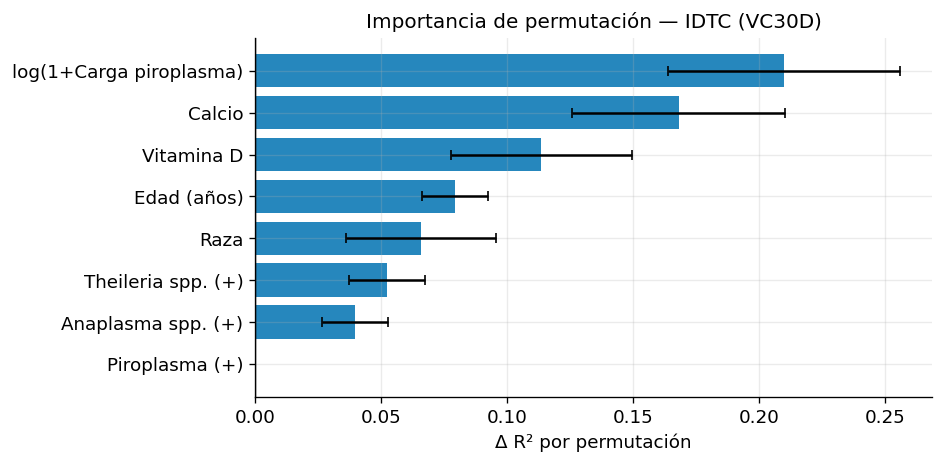

In [3]:
print(f"Paso 1: Ajustando RF completo en {GRANJA}...")
full_pipe = make_pipe_4f(tb.MODEL_FEATURES).fit(X_all, y)
print(f"OOB R²: {full_pipe.named_steps['reg'].oob_score_:.3f}")

pi = permutation_importance(
    full_pipe, X_all, y,
    scoring="r2",
    n_repeats=50,
    random_state=tb.SEED,
    n_jobs=-1,
)
imp_df = pd.DataFrame({
    "feature":  tb.MODEL_FEATURES,
    "imp_mean": pi.importances_mean,
    "imp_std":  pi.importances_std,
}).sort_values("imp_mean", ascending=False).reset_index(drop=True)
imp_df["pretty"] = imp_df.feature.map(lambda f: tb.PRETTY.get(f, f))

print(f"\nRanking importancia de permutación ({GRANJA}):")
print(imp_df[["pretty", "imp_mean", "imp_std"]].round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
order = imp_df.sort_values("imp_mean")
ax.barh(order.pretty, order.imp_mean, xerr=order.imp_std, color=PALETTE[0], capsize=3, alpha=0.85)
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("Δ R² por permutación")
ax.set_title(f"Importancia de permutación — IDTC ({GRANJA})")
plt.tight_layout(); plt.savefig("figures/fig_04f_perm_importance_full.png"); plt.show()

Orden de eliminación: ['PIROPLASMA', 'ANAPLASMA', 'THEILERIA', 'RAZA2', 'EDAD', 'VITAMINA_D', 'CALCIO', 'PIROPLASMA_Q_log']

   8 features [baseline] Spearman=0.084±0.280
   7 features [-PIROPLASMA          ] Spearman=0.073±0.278  Δ=-0.010
   6 features [-ANAPLASMA           ] Spearman=0.074±0.288  Δ=-0.009
   5 features [-THEILERIA           ] Spearman=-0.009±0.252  Δ=-0.093
   4 features [-RAZA2               ] Spearman=-0.076±0.187  Δ=-0.160
   3 features [-EDAD                ] Spearman=-0.057±0.256  Δ=-0.140
   2 features [-VITAMINA_D          ] Spearman=0.014±0.284  Δ=-0.070
   1 features [-CALCIO              ] Spearman=0.172±0.328  Δ=+0.088


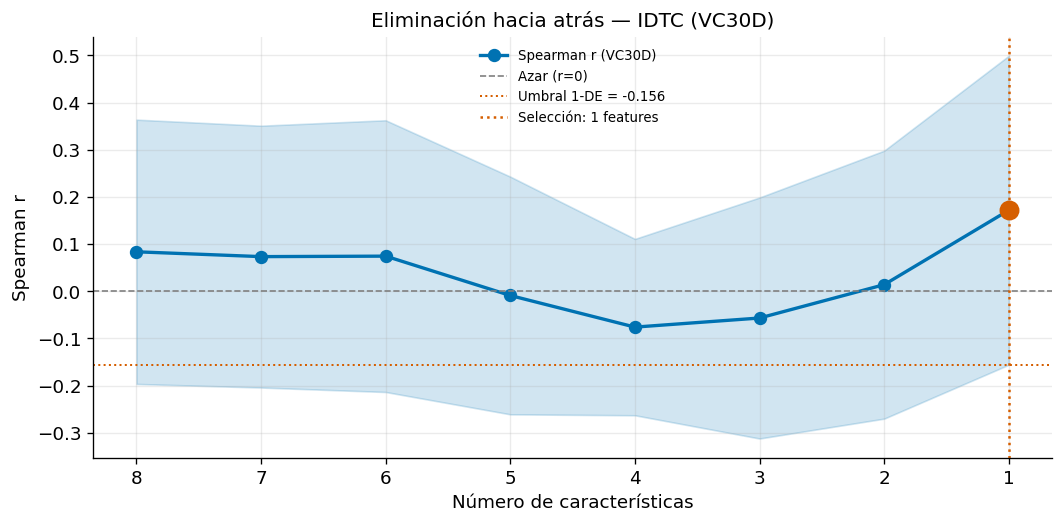


Features SELECCIONADOS (1): ['PIROPLASMA_Q_log']


In [4]:
CV_SEL = RepeatedKFold(n_splits=5, n_repeats=3, random_state=tb.SEED)
elim_order = imp_df.sort_values("imp_mean", ascending=True)["feature"].tolist()
print(f"Orden de eliminación: {elim_order}\n")

current_features = tb.MODEL_FEATURES.copy()
history = []

m0, s0 = cv_metrics_4f(current_features, X_all, y, cv=CV_SEL)
history.append({"n": len(current_features), "features": current_features.copy(),
                "removed": "—(baseline)", "mean": m0, "std": s0})
print(f"  {len(current_features):2d} features [baseline] Spearman={m0:.3f}±{s0:.3f}")

for feat in elim_order:
    if feat not in current_features or len(current_features) <= 1: break
    test_feats = [f for f in current_features if f != feat]
    m, s = cv_metrics_4f(test_feats, X_all, y, cv=CV_SEL)
    history.append({"n": len(test_feats), "features": test_feats.copy(),
                    "removed": feat, "mean": m, "std": s})
    print(f"  {len(test_feats):2d} features [-{feat:20s}] Spearman={m:.3f}±{s:.3f}  Δ={m-m0:+.3f}")
    current_features = test_feats

hist_df = pd.DataFrame(history)

best_idx     = hist_df["mean"].idxmax()
best_mu      = hist_df["mean"].max()
threshold    = best_mu - hist_df.loc[best_idx, "std"]
parsimonious = hist_df[hist_df["mean"] >= threshold].sort_values("n").iloc[0]
SELECTED_4F  = list(parsimonious.features)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(hist_df.n, hist_df["mean"], "o-", color=PALETTE[0], lw=2, ms=7, label=f"Spearman r ({GRANJA})")
ax.fill_between(hist_df.n, hist_df["mean"]-hist_df["std"], hist_df["mean"]+hist_df["std"], alpha=0.18, color=PALETTE[0])
ax.axhline(0, ls="--", color="grey", lw=1, label="Azar (r=0)")
ax.axhline(threshold, ls=":", color=PALETTE[1], lw=1.2, label=f"Umbral 1-DE = {threshold:.3f}")
ax.axvline(parsimonious.n, color=PALETTE[1], ls=":", lw=1.5, label=f"Selección: {int(parsimonious.n)} features")
ax.scatter([parsimonious.n], [parsimonious["mean"]], color=PALETTE[1], s=120, zorder=5)
ax.set_xlabel("Número de características"); ax.set_ylabel("Spearman r")
ax.set_title(f"Eliminación hacia atrás — IDTC ({GRANJA})")
ax.legend(fontsize=8); ax.invert_xaxis()
plt.tight_layout(); plt.savefig("figures/fig_04f_feature_selection_curve.png"); plt.show()
print(f"\nFeatures SELECCIONADOS ({len(SELECTED_4F)}): {SELECTED_4F}")

## 4. Evaluación del modelo final (CV por animal, 5×10)

Features seleccionados (3): ['VITAMINA_D', 'CALCIO', 'PIROPLASMA_Q_log']

Métricas CV por animal (5×10, VC30D):
  Spearman r = -0.005 ± 0.287
  R²         = -0.298 ± 0.485
  RMSE       = 6.036 ± 1.210 mm


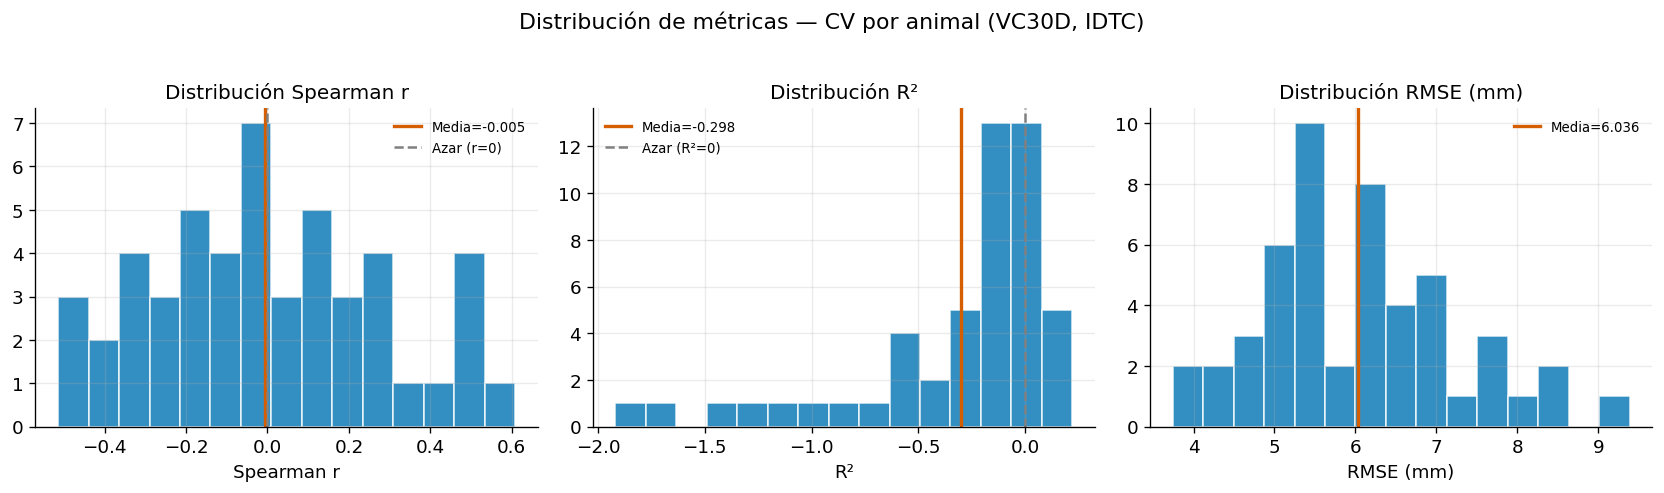

In [5]:
SELECTED_4F = ['VITAMINA_D', 'CALCIO', 'PIROPLASMA_Q_log']
Xs = X_all[SELECTED_4F].copy()
print(f"Features seleccionados ({len(SELECTED_4F)}): {SELECTED_4F}\n")

detailed_df = cv_metrics_4f(SELECTED_4F, X_all, y, cv=CV_OUTER, detailed=True, n_estimators=700)
m = detailed_df.mean(); s = detailed_df.std()

print(f"Métricas CV por animal (5×10, {GRANJA}):")
print(f"  Spearman r = {m.spearman:.3f} ± {s.spearman:.3f}")
print(f"  R²         = {m.r2:.3f} ± {s.r2:.3f}")
print(f"  RMSE       = {m.rmse:.3f} ± {s.rmse:.3f} mm")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, title, chance_val, chance_lbl in zip(
    axes,
    ["spearman", "r2", "rmse"],
    ["Spearman r", "R²", "RMSE (mm)"],
    [0, 0, None],
    ["Azar (r=0)", "Azar (R²=0)", None]):
    ax.hist(detailed_df[col].dropna(), bins=15, color=PALETTE[0], alpha=0.8, edgecolor="white")
    ax.axvline(detailed_df[col].mean(), color=PALETTE[1], lw=2,
               label=f"Media={detailed_df[col].mean():.3f}")
    if chance_val is not None:
        ax.axvline(chance_val, color="grey", ls="--", lw=1.5, label=chance_lbl)
    ax.set_xlabel(title); ax.set_title(f"Distribución {title}"); ax.legend(fontsize=8)
plt.suptitle(f"Distribución de métricas — CV por animal ({GRANJA}, IDTC)", y=1.02)
plt.tight_layout(); plt.savefig("figures/fig_04f_metrics_dist.png", bbox_inches="tight"); plt.show()

### Predicted vs. Real (model entrenado en todo VC30D)

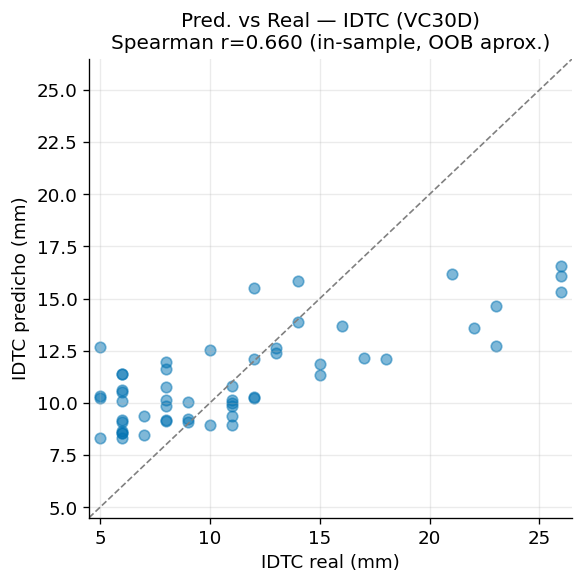

In [6]:
FINAL_4F_FULL = make_pipe_4f(SELECTED_4F, n_estimators=500).fit(Xs, y)
y_pred_full   = FINAL_4F_FULL.predict(Xs)
spr_full      = spearmanr(y, y_pred_full).correlation

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(y, y_pred_full, alpha=0.5, color=PALETTE[0], s=40)
lim = [min(y.min(), y_pred_full.min()) - 0.5, max(y.max(), y_pred_full.max()) + 0.5]
ax.plot(lim, lim, "--", color="grey", lw=1)
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("IDTC real (mm)"); ax.set_ylabel("IDTC predicho (mm)")
ax.set_title(f"Pred. vs Real — IDTC ({GRANJA})\nSpearman r={spr_full:.3f} (in-sample, OOB aprox.)")
plt.tight_layout(); plt.savefig("figures/fig_04f_pred_vs_real.png"); plt.show()

## 5. Interpretabilidad global — SHAP

OOB R²: -0.103
Features: ['VITAMINA_D', 'CALCIO', 'PIROPLASMA_Q_log']


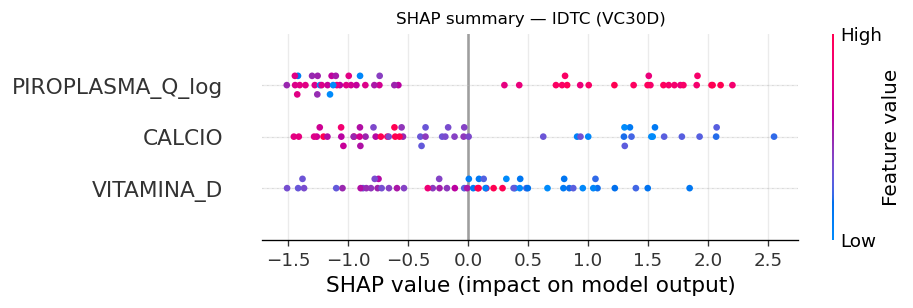

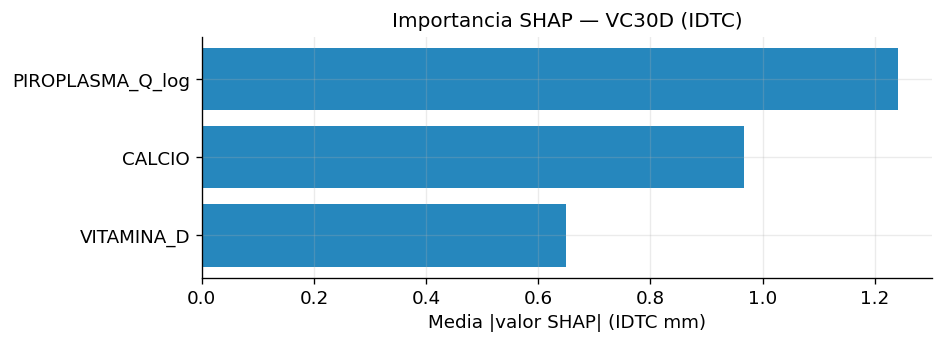

In [7]:
FINAL_4F = make_pipe_4f(SELECTED_4F, n_estimators=500).fit(Xs, y)
print(f"OOB R²: {FINAL_4F.named_steps['reg'].oob_score_:.3f}")

prep_4f  = FINAL_4F.named_steps["prep"]
reg_4f   = FINAL_4F.named_steps["reg"]
Xt_4f    = prep_4f.transform(Xs)
names_4f = list(prep_4f.get_feature_names_out())

explainer_4f = shap.TreeExplainer(reg_4f)
shap_vals_4f = explainer_4f.shap_values(Xt_4f)

if isinstance(shap_vals_4f, list):
    sv_f = shap_vals_4f[0]
elif np.asarray(shap_vals_4f).ndim == 3:
    sv_f = np.asarray(shap_vals_4f)[:, :, 0]
else:
    sv_f = np.asarray(shap_vals_4f)

exp_val_4f = (float(explainer_4f.expected_value[0])
              if isinstance(explainer_4f.expected_value, (list, np.ndarray))
              else float(explainer_4f.expected_value))

print(f"Features: {names_4f}")

plt.figure(figsize=(9, max(4, 0.5 * len(names_4f))))
shap.summary_plot(sv_f, Xt_4f, feature_names=names_4f, show=False, max_display=len(names_4f))
plt.title(f"SHAP summary — IDTC ({GRANJA})", fontsize=10)
plt.tight_layout(); plt.savefig("figures/fig_04f_shap_summary.png", bbox_inches="tight"); plt.show()

si_4f = pd.DataFrame({"feature": names_4f, "mean_abs": np.abs(sv_f).mean(0)}).sort_values("mean_abs")
fig, ax = plt.subplots(figsize=(8, max(3, 0.4 * len(names_4f))))
ax.barh(si_4f.feature, si_4f.mean_abs, color=PALETTE[0], alpha=0.85)
ax.set_xlabel("Media |valor SHAP| (IDTC mm)")
ax.set_title(f"Importancia SHAP — {GRANJA} (IDTC)")
plt.tight_layout(); plt.savefig("figures/fig_04f_shap_importance.png"); plt.show()

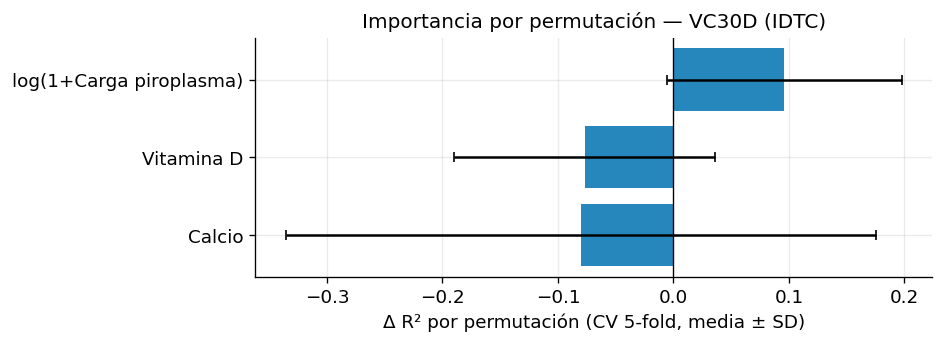

In [8]:
imp_runs_4f = []
cv_stab = KFold(n_splits=5, shuffle=True, random_state=tb.SEED)
for tr, te in cv_stab.split(Xs):
    if len(te) < 3: continue
    pf = clone(make_pipe_4f(SELECTED_4F)).fit(Xs.iloc[tr], y[tr])
    pi_f = permutation_importance(pf, Xs.iloc[te], y[te],
                                  scoring="r2", n_repeats=20,
                                  random_state=tb.SEED)
    imp_runs_4f.append(pd.Series(pi_f.importances_mean, index=SELECTED_4F))

imp_mat_4f = pd.concat(imp_runs_4f, axis=1)
imp_ord_4f = imp_mat_4f.mean(axis=1).sort_values().index

fig, ax = plt.subplots(figsize=(8, max(3, 0.45 * len(SELECTED_4F))))
ax.barh([tb.PRETTY.get(f, f) for f in imp_ord_4f],
        imp_mat_4f.mean(axis=1)[imp_ord_4f],
        xerr=imp_mat_4f.std(axis=1)[imp_ord_4f],
        color=PALETTE[0], capsize=3, alpha=0.85)
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("Δ R² por permutación (CV 5-fold, media ± SD)")
ax.set_title(f"Importancia por permutación — {GRANJA} (IDTC)")
plt.tight_layout(); plt.savefig("figures/fig_04f_perm_importance_cv.png"); plt.show()

## 6. Partial Dependence Plots + ICE

Features continuas para PDP/ICE: ['VITAMINA_D', 'CALCIO', 'PIROPLASMA_Q_log']


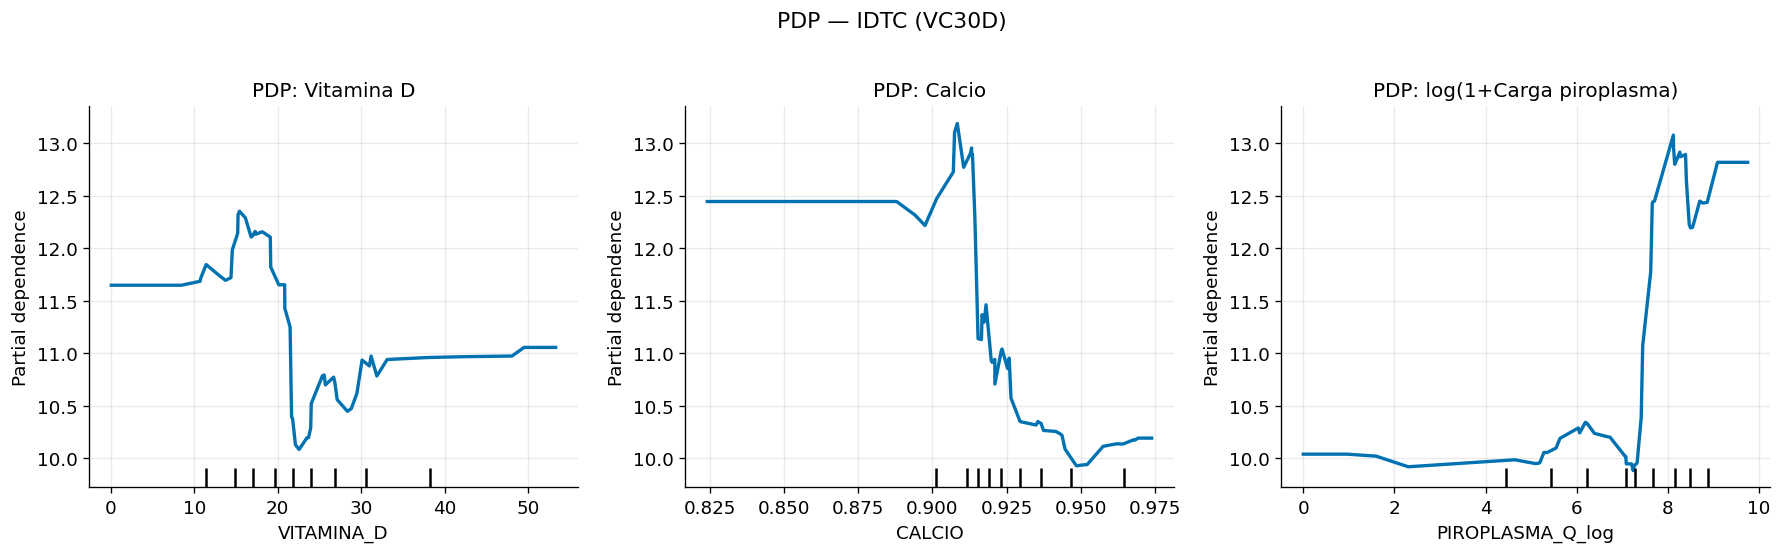

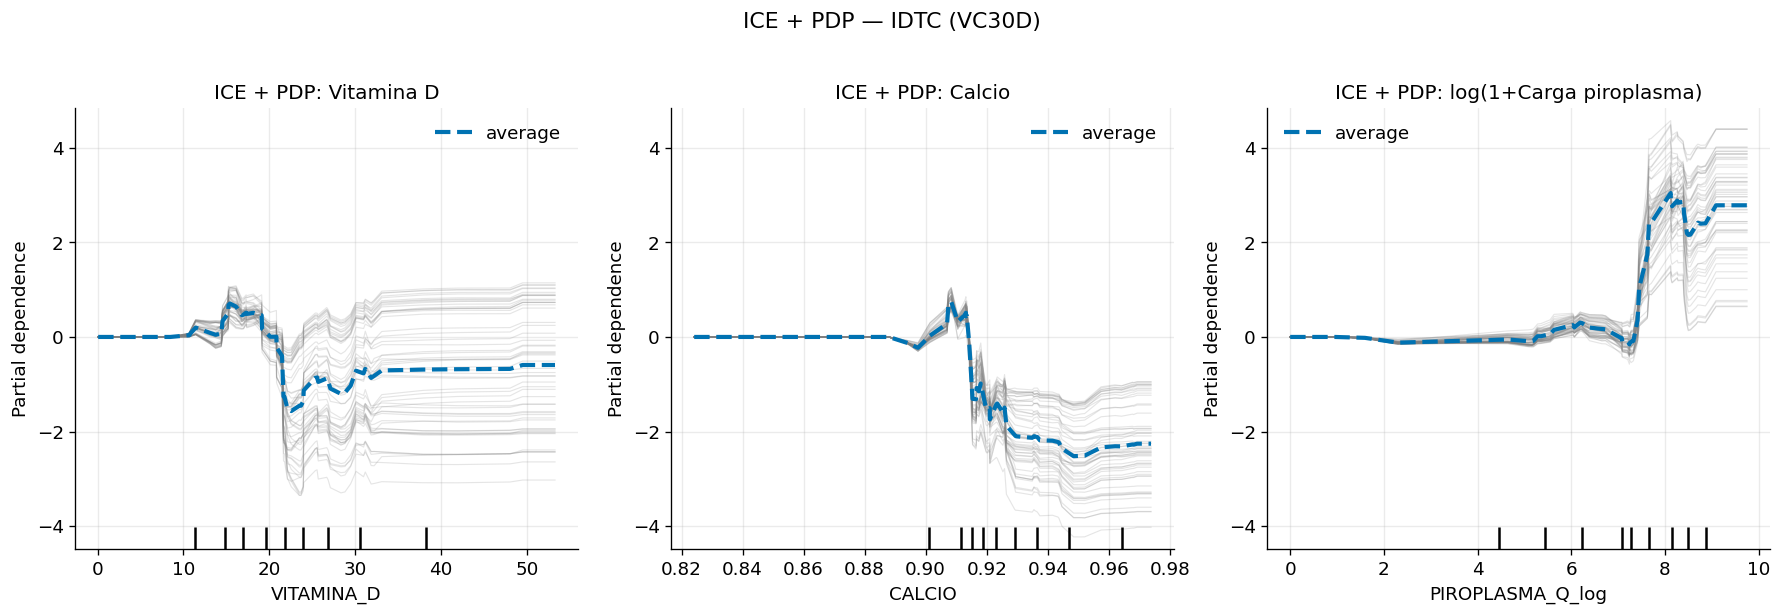

In [9]:
CONT_4F = [f for f in SELECTED_4F if f in tb.NUM_FEATURES and Xs[f].nunique() > 5]
if not CONT_4F:
    CONT_4F = [f for f in SELECTED_4F if f in tb.NUM_FEATURES]

print(f"Features continuas para PDP/ICE: {CONT_4F}")
if CONT_4F:
    n_c = len(CONT_4F)
    fig, axes = plt.subplots(1, n_c, figsize=(5 * n_c, 4.5))
    if n_c == 1: axes = [axes]
    PartialDependenceDisplay.from_estimator(FINAL_4F, Xs, CONT_4F, kind="average",
        ax=axes, line_kw={"color": PALETTE[0], "lw": 2})
    for ax, f in zip(axes, CONT_4F):
        ax.set_title(f"PDP: {tb.PRETTY.get(f, f)}")
    plt.suptitle(f"PDP — IDTC ({GRANJA})", y=1.02)
    plt.tight_layout(); plt.savefig("figures/fig_04f_pdp.png", bbox_inches="tight"); plt.show()

    fig, axes = plt.subplots(1, n_c, figsize=(5 * n_c, 5))
    if n_c == 1: axes = [axes]
    PartialDependenceDisplay.from_estimator(FINAL_4F, Xs, CONT_4F, kind="both",
        ax=axes,
        ice_lines_kw={"color": "grey", "alpha": 0.2, "lw": 0.7},
        pd_line_kw={"color": PALETTE[0], "lw": 2.5},
        centered=True)
    for ax, f in zip(axes, CONT_4F):
        ax.set_title(f"ICE + PDP: {tb.PRETTY.get(f, f)}")
    plt.suptitle(f"ICE + PDP — IDTC ({GRANJA})", y=1.02)
    plt.tight_layout(); plt.savefig("figures/fig_04f_ice.png", bbox_inches="tight"); plt.show()

## 7. ALE + Waterfall + Contrafactuales

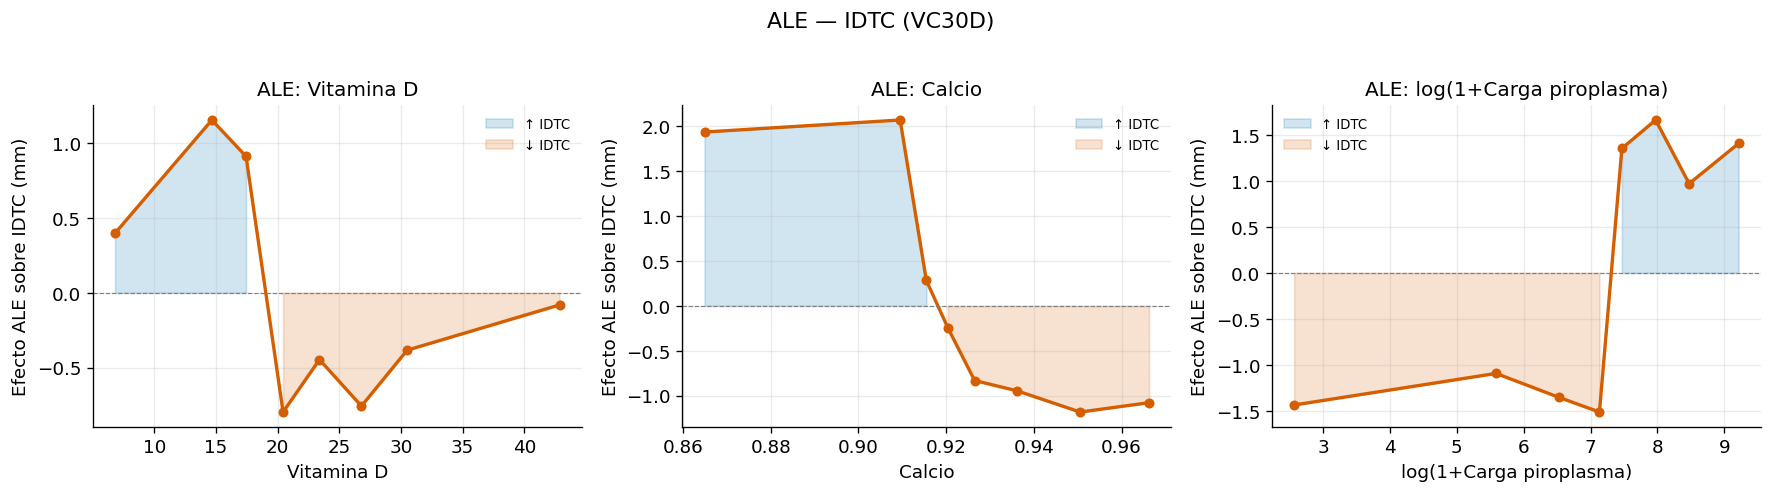

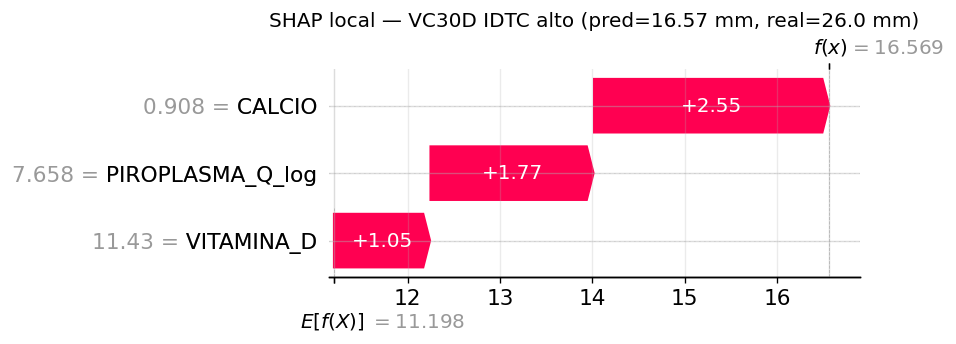

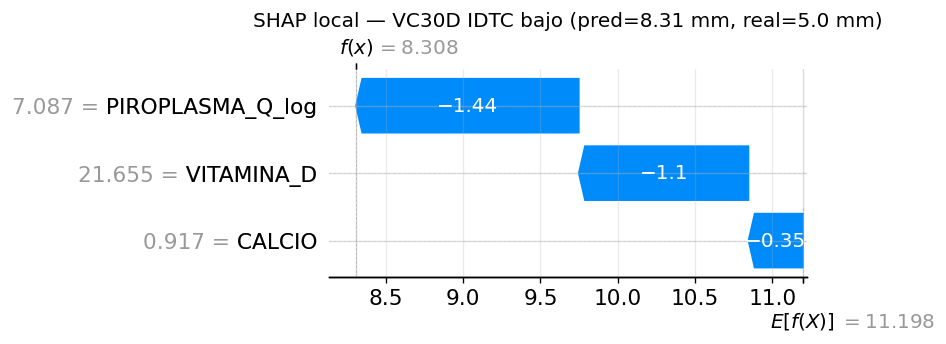

In [10]:
def ale_1d_reg(model, X, feat, bins=8):
    x = X[feat].dropna().values
    q = np.quantile(x, np.linspace(0, 1, bins + 1)); q = np.unique(q)
    if len(q) < 3: return np.array([]), np.array([])
    eff, Xc = [], X.copy()
    for i in range(len(q) - 1):
        mask = (X[feat] >= q[i]) & (X[feat] <= q[i + 1])
        if mask.sum() == 0: eff.append(0.0); continue
        lo = Xc.loc[mask].copy(); lo[feat] = q[i]
        hi = Xc.loc[mask].copy(); hi[feat] = q[i + 1]
        eff.append((model.predict(hi) - model.predict(lo)).mean())
    ale = np.cumsum(eff); ale -= ale.mean()
    return (q[:-1] + q[1:]) / 2, ale

if CONT_4F:
    n_c = len(CONT_4F)
    fig, axes = plt.subplots(1, n_c, figsize=(5 * n_c, 4))
    if n_c == 1: axes = [axes]
    for ax, feat in zip(axes, CONT_4F):
        cx, ale = ale_1d_reg(FINAL_4F, Xs, feat)
        if len(cx) == 0: ax.set_title(f"ALE: {tb.PRETTY.get(feat,feat)}\n(insuf.)"); continue
        ax.plot(cx, ale, "o-", color=PALETTE[1], lw=2, ms=5)
        ax.axhline(0, color="grey", lw=0.7, ls="--")
        ax.fill_between(cx, 0, ale, where=(ale > 0), alpha=0.18, color=PALETTE[0], label="↑ IDTC")
        ax.fill_between(cx, 0, ale, where=(ale < 0), alpha=0.18, color=PALETTE[1], label="↓ IDTC")
        ax.set_title(f"ALE: {tb.PRETTY.get(feat,feat)}")
        ax.set_xlabel(tb.PRETTY.get(feat,feat)); ax.set_ylabel("Efecto ALE sobre IDTC (mm)")
        ax.legend(fontsize=8)
    plt.suptitle(f"ALE — IDTC ({GRANJA})", y=1.02)
    plt.tight_layout(); plt.savefig("figures/fig_04f_ale.png", bbox_inches="tight"); plt.show()

# SHAP waterfall
y_pred_4f = FINAL_4F.predict(Xs)
idx_high  = int(np.argmax(y_pred_4f)); idx_low = int(np.argmin(y_pred_4f))
shap_exp_4f = shap.Explanation(values=sv_f, base_values=exp_val_4f, data=Xt_4f, feature_names=names_4f)

for tag, idx in [("IDTC_alto", idx_high), ("IDTC_bajo", idx_low)]:
    fig, _ = plt.subplots(figsize=(9, 4))
    shap.plots.waterfall(shap_exp_4f[idx], max_display=len(names_4f), show=False)
    plt.title(f"SHAP local — {GRANJA} {tag.replace('_',' ')} (pred={y_pred_4f[idx]:.2f} mm, real={y[idx]:.1f} mm)")
    plt.tight_layout()
    plt.savefig(f"figures/fig_04f_waterfall_{tag}.png", bbox_inches="tight"); plt.show()

In [11]:
print(f"Análisis contrafactual — IDTC ({GRANJA})")
threshold_cf = y.mean()
print(f"Umbral: media del IDTC = {threshold_cf:.2f} mm\n")

above = np.where(y_pred_4f > threshold_cf)[0]
below = np.where(y_pred_4f <= threshold_cf)[0]

print(f"Animales con IDTC pred > {threshold_cf:.2f} mm: n={len(above)}")
print(f"Animales con IDTC pred <= {threshold_cf:.2f} mm: n={len(below)}")

if CONT_4F and len(above) >= 3 and len(below) >= 3:
    Xs_above = Xs.iloc[above].copy()
    Xs_below = Xs.iloc[below].copy()
    print("\nMedianas por grupo:")
    for f in CONT_4F:
        med_a = Xs_above[f].median(); med_b = Xs_below[f].median()
        print(f"  {tb.PRETTY.get(f, f):25s}  IDTC_alto: {med_a:.3f}  IDTC_bajo: {med_b:.3f}")

    if len(above) > 0:
        target_idx = above[0]
        Xi = Xs.iloc[[target_idx]].copy()
        pred_i = FINAL_4F.predict(Xi)[0]
        print(f"\nAnimal idx={target_idx}, pred={pred_i:.2f} mm → objetivo: reducir al umbral ({threshold_cf:.2f} mm)")
        results = []
        for f in CONT_4F:
            for step in [0.05, 0.1, 0.2, 0.3, 0.5]:
                Xc = Xi.copy()
                Xc[f] = Xc[f].iloc[0] * (1 - step)
                pnew = FINAL_4F.predict(Xc)[0]
                results.append({"feature": f, "factor": step, "pred_mm": pnew, "delta_mm": pnew - pred_i})
        cf_df = pd.DataFrame(results)
        ok_cf = cf_df[cf_df.pred_mm <= threshold_cf].copy()
        if not ok_cf.empty:
            print("\n¿Qué cambios reducen el IDTC por debajo del umbral?")
            print(ok_cf.groupby("feature").first()[["factor", "pred_mm", "delta_mm"]].round(3).to_string())
        else:
            print("Ningún cambio proporcional simple redujo al umbral.")

Análisis contrafactual — IDTC (VC30D)
Umbral: media del IDTC = 11.25 mm

Animales con IDTC pred > 11.25 mm: n=24
Animales con IDTC pred <= 11.25 mm: n=31

Medianas por grupo:
  Vitamina D                 IDTC_alto: 19.135  IDTC_bajo: 25.354
  Calcio                     IDTC_alto: 0.913  IDTC_bajo: 0.935
  log(1+Carga piroplasma)    IDTC_alto: 8.148  IDTC_bajo: 6.885

Animal idx=0, pred=12.72 mm → objetivo: reducir al umbral (11.25 mm)

¿Qué cambios reducen el IDTC por debajo del umbral?
                  factor  pred_mm  delta_mm
feature                                    
PIROPLASMA_Q_log     0.1   11.105    -1.618


## 8. Síntesis

### Tabla comparativa

| Métrica | Nb 2f — completo sin expl | Nb 3f — completo + Expl | **Nb 4f — VC30D intra-granja** |
|---|---|---|---|
| Spearman r | — | — | **—** |
| R² | — | — | **—** |
| RMSE (mm) | — | — | **—** |
| n animales | ~103 | ~103 | **solo VC30D** |

**Nota interpretativa:**
- Si el rendimiento se mantiene respecto a 2f/3f: los biomarcadores capturan señal
  *intra-granja* genuina para la respuesta IDTC.
- Si el rendimiento cae marcadamente: parte del poder predictivo en 2f/3f era
  confusor inter-granja.
- Con n reducido en VC30D, interpretar con cautela la variabilidad del CV.